In [12]:
#libraries 
#data frame and series manipulation 
import pandas as pd 
#plot 
import matplotlib.pyplot as plt 
#stastical and visualization 
import seaborn as sns
#NLP 
import nltk
#string identifier and function
import string
#to count frequency of elements in an iterable or mapping efficiently 
from collections import Counter
#Sastrawi Indonesian stopwords from NLTK for text preprocessing 
import Sastrawi 
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory 
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.stem import WordNetLemmatizer 
#
import re
from google_play_scraper import app , Sort , reviews_all


In [11]:
!pip install google_play_scraper

In [4]:
nltk.download('stopwords')
from nltk.corpus import stopwords
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...


True

In [13]:
#Import the Data from nhs_reviews
nhs_reviews = reviews_all(
    'com.microsoft.planner',
    sleep_milliseconds=0,
    lang='en',
    sort=Sort.NEWEST
)

In [19]:
df_nhsrev = pd.DataFrame(nhs_reviews)
df_nhsrev.head()


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,4ffe5822-3388-42d6-b0aa-0b637d397320,Matthew Pieterse,https://play-lh.googleusercontent.com/a-/ALV-U...,Lagging far behind the desktop/web UI experien...,1,0,1.18.36,2026-03-24 22:39:25,NaN,NaT,1.18.36
1,12098749-597c-4c0c-afbd-ee6285b78449,Ephraim Nkemachor,https://play-lh.googleusercontent.com/a-/ALV-U...,interface barely ever works,1,0,1.18.31,2026-03-23 22:01:55,NaN,NaT,1.18.31
2,0241cd90-484f-442d-86ad-0b84b6d865f6,딸기,https://play-lh.googleusercontent.com/a/ACg8oc...,it's good but hope there'll be notification fe...,4,0,NaN,2026-03-12 09:21:46,NaN,NaT,NaN
3,d5a759cd-b785-4818-a4ea-f80ee119074e,Tom O,https://play-lh.googleusercontent.com/a/ACg8oc...,I can only see one of many plans,1,0,1.18.36,2026-03-11 05:14:39,NaN,NaT,1.18.36
4,f5a76d6b-6e4c-44da-b1a6-d1cdb641ec59,Roke Beedell (RokeJulianLockhart),https://play-lh.googleusercontent.com/a-/ALV-U...,Does not integrate with To-Do.,2,0,NaN,2026-03-09 18:37:37,NaN,NaT,NaN


In [ ]:
df_nhsrev.to_csv(r"C:\Users\USER\Documents\PBA\week4\2_BagOfWords\planner_review.csv", index=False)

In [20]:
#create Stemmer and Lemmatizer 
factory = StemmerFactory()
stemmer = factory.create_stemmer()
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    #case lowering 
    text = text.lower()
    #punctuation removal 
    text = re.sub(r'[^\w\s]', '', text)
    #stemming 
    text = stemmer.stem(text)
    #Lemmatization (requires a part -of-speech tag for optimal results)
    words = text.split()
    lemmatized_words = [lemmatizer.lemmatize(word, 'v') for word in words]
    text = ' ' .join(lemmatized_words)

    return text
#Apply the cleaning function to the 'review' column
df_nhsrev['cleaned_review'] = df_nhsrev['content'].apply(clean_text)

#Display the DataFrame with the cleaned reviews 
print(df_nhsrev[['content', 'cleaned_review']])



                                                content  \
0     Lagging far behind the desktop/web UI experien...   
1                           interface barely ever works   
2     it's good but hope there'll be notification fe...   
3                      I can only see one of many plans   
4                        Does not integrate with To-Do.   
...                                                 ...   
2838  Limited functionality.  Can't add tasks or pla...   
2839                                        Works well.   
2840  Fantastic! This is what I was waiting for and ...   
2841  A good first version. Excited for more Planner...   
2842                                  Clean and simple.   

                                         cleaned_review  
0     lag far behind the desktopweb ui experience th...  
1                            interface barely ever work  
2     its good but hope therell be notification feat...  
3                       i can only see one of many plan  
4

In [22]:
#Data OverView
#Convert 'at' column to datetime format 
df_nhsrev['at'] = pd.to_datetime(df_nhsrev['at'])

#Display dataset infor and first few rows 
df_nhsrev.info()
df_nhsrev.head()

<class 'pandas.DataFrame'>
RangeIndex: 2843 entries, 0 to 2842
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              2843 non-null   str           
 1   userName              2843 non-null   str           
 2   userImage             2843 non-null   str           
 3   content               2843 non-null   str           
 4   score                 2843 non-null   int64         
 5   thumbsUpCount         2843 non-null   int64         
 6   reviewCreatedVersion  2546 non-null   str           
 7   at                    2843 non-null   datetime64[us]
 8   replyContent          364 non-null    str           
 9   repliedAt             364 non-null    datetime64[us]
 10  appVersion            2546 non-null   str           
 11  cleaned_review        2843 non-null   str           
dtypes: datetime64[us](2), int64(2), str(8)
memory usage: 266.7 KB


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,cleaned_review
0,4ffe5822-3388-42d6-b0aa-0b637d397320,Matthew Pieterse,https://play-lh.googleusercontent.com/a-/ALV-U...,Lagging far behind the desktop/web UI experien...,1,0,1.18.36,2026-03-24 22:39:25,NaN,NaT,1.18.36,lag far behind the desktopweb ui experience th...
1,12098749-597c-4c0c-afbd-ee6285b78449,Ephraim Nkemachor,https://play-lh.googleusercontent.com/a-/ALV-U...,interface barely ever works,1,0,1.18.31,2026-03-23 22:01:55,NaN,NaT,1.18.31,interface barely ever work
2,0241cd90-484f-442d-86ad-0b84b6d865f6,딸기,https://play-lh.googleusercontent.com/a/ACg8oc...,it's good but hope there'll be notification fe...,4,0,NaN,2026-03-12 09:21:46,NaN,NaT,NaN,its good but hope therell be notification feat...
3,d5a759cd-b785-4818-a4ea-f80ee119074e,Tom O,https://play-lh.googleusercontent.com/a/ACg8oc...,I can only see one of many plans,1,0,1.18.36,2026-03-11 05:14:39,NaN,NaT,1.18.36,i can only see one of many plan
4,f5a76d6b-6e4c-44da-b1a6-d1cdb641ec59,Roke Beedell (RokeJulianLockhart),https://play-lh.googleusercontent.com/a-/ALV-U...,Does not integrate with To-Do.,2,0,NaN,2026-03-09 18:37:37,NaN,NaT,NaN,do not integrate with todo


In [24]:
#Missing Value Analysis 
missing_values = df_nhsrev.isnull().sum()
print("Missing Values Summary:")
print(missing_values)

Missing Values Summary:
reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
reviewCreatedVersion     297
at                         0
replyContent            2479
repliedAt               2479
appVersion               297
cleaned_review             0
dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_1332\3223840086.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_nhsrev['score'], palette="viridis")


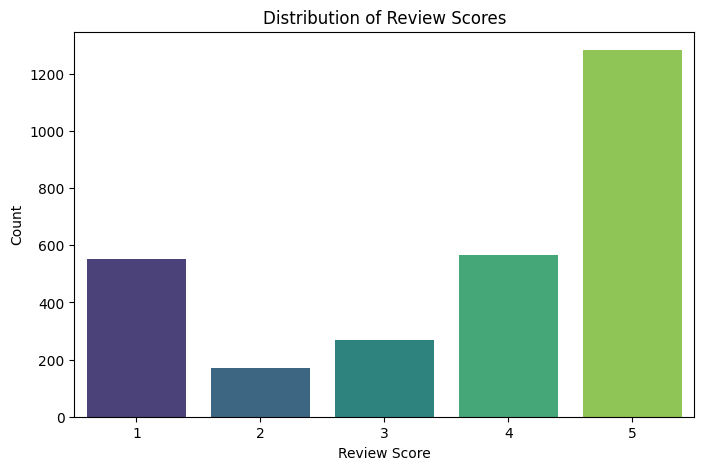

In [26]:
#Review Score Distribution
plt.figure(figsize=(8,5))
sns.countplot(x=df_nhsrev['score'], palette="viridis")
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()

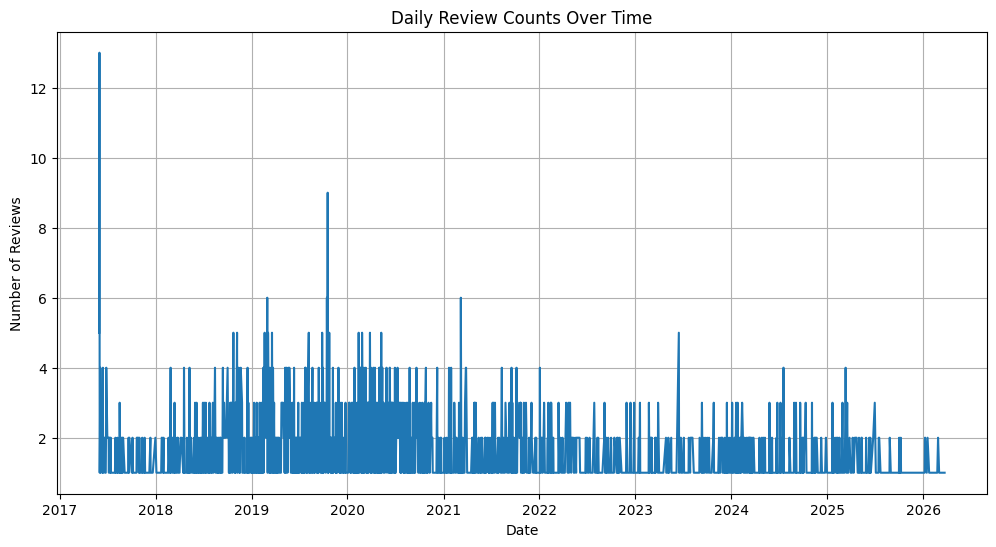

In [30]:
#Review Trends Over Time 
#Extract Review date 
df_nhsrev['review_date'] = df_nhsrev['at'].dt.date
review_trend = df_nhsrev.groupby('review_date').size()

plt.figure(figsize=(12, 6))
review_trend.plot()
plt.title("Daily Review Counts Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")
plt.grid(True)
plt.show()

In [33]:
#Word Frequency Analysis 
stop_words = set(stopwords.words('english'))
#combine all review text 
all_reviews = " ".join(df_nhsrev['content'].dropna()).lower()
all_reviews = all_reviews.translate(str.maketrans("","",string.punctuation))

#Tokenization and filtering words 
words = all_reviews.split()
filtered_words = [word for word in words if word not in stop_words]

#Counting word occurences 
word_counts = Counter(filtered_words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

# Counting word occurrences
word_counts = Counter(filtered_words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

# Display most common words
print("Most Common Words in Reviews:")
print(common_words)

Most Common Words in Reviews:
         Word  Frequency
0         app        868
1       tasks        445
2       great        421
3         use        391
4        good        371
5        work        323
6     planner        303
7        task        241
8   microsoft        228
9       would        202
10       like        192
11       easy        191
12       cant        184
13       tool        168
14       team        157
15      teams        151
16       time        135
17    account        132
18       need        132
19       plan        127
